<a href="https://colab.research.google.com/github/Alina-Smol/prolongation/blob/main/prolongations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Отчёт по пролонгациям договоров за 2023 год
Логика расчёта коэффициентов пролонгации

**Коэффициент пролонгации 1-го месяца:**
- Числитель: сумма отгрузок в месяце M по проектам, завершившимся в месяце M-1 и имеющим отгрузку в месяце M
- Знаменатель: сумма отгрузок в последнем месяце (M-1) по всем проектам, завершившимся в месяце M-1

**Коэффициент пролонгации 2-го месяца:**
- Числитель: сумма отгрузок в месяце M по проектам, завершившимся в месяце M-2, не имевшим отгрузки в M-1, но имеющим отгрузку в M
- Знаменатель: сумма отгрузок в последнем месяце (M-2) по проектам, завершившимся в M-2 И не имевшим отгрузки в M-1

**Обработка специальных значений:**
- в ноль -> 0 (если все части оплаты = 0, берём отгрузку предыдущего месяца)
- стоп / end -> проект исключаем из расчёта, если статус встречается в последний месяц реализации или ранее

## **1. Импорт данных и предварительная обработка**

In [1254]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style="whitegrid")

# Загрузка данных
prolongations = pd.read_csv('prolongations.csv', sep=',')
financial = pd.read_csv('financial_data.csv', sep=',')

print(f"prolongations: {prolongations.shape}")
print(f"financial: {financial.shape}")
prolongations
# financial

prolongations: (477, 3)
financial: (451, 19)


,id,month,AM
0,42,ноябрь 2022,Васильев Артем Александрович
1,453,ноябрь 2022,Васильев Артем Александрович
2,548,ноябрь 2022,Михайлов Андрей Сергеевич
3,87,ноябрь 2022,Соколова Анастасия Викторовна
4,429,ноябрь 2022,Соколова Анастасия Викторовна
...,...,...,...
472,955,декабрь 2023,Смирнова Ольга Владимировна
473,1004,декабрь 2023,без А/М
474,281,декабрь 2023,Соколова Анастасия Викторовна
475,785,декабрь 2023,Соколова Анастасия Викторовна


Подготовка данных к расчету коэффициентов.

*   Проверка данных на пустые строки/ячейки ->
*   Привидение форматов дат мм.гггг
*   Преобразование денег в float
*   удаление строк с преостановленными проектами


In [1255]:
def preprocess_data(df):
    # Типы данных и пропуски
    print("\n Типы данных и пропущенные значения:")
    info_df = pd.DataFrame({
        'dtype': df.dtypes,
        'missing_count': df.isnull().sum(),
        'unique_count': df.nunique()
    })
    print(info_df)

    # Статистики для числовых колонок
    print("\n Статистики числовых переменных:")
    print(df.describe().T)

preprocess_data(prolongations)
print('-----------------------------------------------------------------------------')
preprocess_data(financial)


 Типы данных и пропущенные значения:
        dtype  missing_count  unique_count
id      int64              0           313
month  object              0            14
AM     object              0            10

 Статистики числовых переменных:
    count        mean         std   min    25%    50%    75%     max
id  477.0  630.327044  260.636281  15.0  495.0  692.0  823.0  1015.0
-----------------------------------------------------------------------------

 Типы данных и пропущенные значения:
                dtype  missing_count  unique_count
id              int64              0           314
Причина дубля  object            150             6
Ноябрь 2022    object            295           142
Декабрь 2022   object            292           140
Январь 2023    object            312           134
Февраль 2023   object            306           138
Март 2023      object            283           162
Апрель 2023    object            277           161
Май 2023       object            261       

In [1256]:
# Функция для парсинга месяцев в формат 'месяц год'
def parse_month(month_str):
  months = {
    'январь': 1, 'февраль': 2, 'март': 3, 'апрель': 4,
    'май': 5, 'июнь': 6, 'июль': 7, 'август': 8,
    'сентябрь': 9, 'октябрь': 10, 'ноябрь': 11, 'декабрь': 12
  }

  parts = month_str.strip().split()
  month = parts[0].lower()
  year = int(parts[1])
  return pd.Timestamp(year=year, month=months[month], day=1)

prolongations['month_dt'] = prolongations['month'].apply(lambda x: parse_month(x))
prolongations['last_month'] = prolongations['month_dt'].dt.to_period('M')

print(prolongations.head())

    id        month                             AM   month_dt last_month
0   42  ноябрь 2022   Васильев Артем Александрович 2022-11-01    2022-11
1  453  ноябрь 2022   Васильев Артем Александрович 2022-11-01    2022-11
2  548  ноябрь 2022      Михайлов Андрей Сергеевич 2022-11-01    2022-11
3   87  ноябрь 2022  Соколова Анастасия Викторовна 2022-11-01    2022-11
4  429  ноябрь 2022  Соколова Анастасия Викторовна 2022-11-01    2022-11


Преобразуем в вертикальную таблицу для удобства.


In [1257]:
# колонки с месяцами из financial.csv
month_columns = [col for col in financial.columns if col not in ['id', 'Причина дубля', 'Account']]
print(f"Месячные колонки: {month_columns}")

financial_vertical = financial.melt(
    id_vars=['id', 'Причина дубля', 'Account'],
    value_vars=month_columns,
    var_name='month',
    value_name='amount'
)
financial_vertical = financial_vertical.dropna(subset=['amount'])
financial_vertical['month_period'] = financial_vertical['month'].apply(parse_month)
financial_vertical['month_period'] = financial_vertical['month_period'].dt.to_period('M')
financial_vertical.head()

Месячные колонки: ['Ноябрь 2022', 'Декабрь 2022', 'Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023', 'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023', 'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023', 'Январь 2024', 'Февраль 2024']


,id,Причина дубля,Account,month,amount,month_period
0,42,NaN,Васильев Артем Александрович,Ноябрь 2022,"36 220,00",2022-11
1,657,первая часть оплаты,Васильев Артем Александрович,Ноябрь 2022,стоп,2022-11
2,657,вторая часть оплаты,Васильев Артем Александрович,Ноябрь 2022,стоп,2022-11
3,594,NaN,Васильев Артем Александрович,Ноябрь 2022,стоп,2022-11
4,665,NaN,Васильев Артем Александрович,Ноябрь 2022,"10 000,00",2022-11


In [1258]:
# функция для преобразования в числовой формат + обработка специальных значений 'стоп', 'end', 'в ноль'
def clean_amount(value):
    if pd.isna(value) or str(value).strip() == '':
        return np.nan
    val_str = str(value).strip().lower()
    if val_str in ['стоп', 'end']:
        return 'STOP'
    if val_str == 'в ноль':
        return 0.0
    cleaned = val_str.replace('\xa0', '').replace(' ', '').replace(',', '.')
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

financial_vertical['amount_clean'] = financial_vertical['amount'].apply(clean_amount)
# объединение двух таблиц
financial_vertical = financial_vertical.merge(
    prolongations[['id', 'last_month']],
    on='id',
    how='inner'
)

mask_stop = (financial_vertical['amount_clean'] == 'STOP') & \
            (financial_vertical['month_period'] <= financial_vertical['last_month']) & \
            (financial_vertical['last_month'].notna())
stopped_ids = financial_vertical.loc[mask_stop, 'id'].unique()
financial_vertical = financial_vertical[~financial_vertical['id'].isin(stopped_ids)]

financial_vertical['amount_clean'] = financial_vertical['amount_clean'].replace('STOP', np.nan)
financial_vertical = financial_vertical.dropna(subset=['amount_clean'])

financial_vertical

/tmp/ipykernel_2920/3050347603.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  financial_vertical['amount_clean'] = financial_vertical['amount_clean'].replace('STOP', np.nan)


,id,Причина дубля,Account,month,amount,month_period,amount_clean,last_month
0,42,NaN,Васильев Артем Александрович,Ноябрь 2022,"36 220,00",2022-11,36220.0,2022-11
4,665,NaN,Васильев Артем Александрович,Ноябрь 2022,"10 000,00",2022-11,10000.0,2022-11
5,637,NaN,Соколова Анастасия Викторовна,Ноябрь 2022,"38 045,00",2022-11,38045.0,2022-11
6,578,NaN,Попова Екатерина Николаевна,Ноябрь 2022,"82 800,00",2022-11,82800.0,2022-11
7,579,NaN,Васильев Артем Александрович,Ноябрь 2022,в ноль,2022-11,0.0,2022-11
...,...,...,...,...,...,...,...,...
4866,350,первая часть оплаты,Смирнова Ольга Владимировна,Февраль 2024,"117 500,00",2024-02,117500.0,2023-12
4867,350,вторая часть оплаты,Смирнова Ольга Владимировна,Февраль 2024,"305,00",2024-02,305.0,2023-12
4868,281,основные работы,Соколова Анастасия Викторовна,Февраль 2024,"92 065,00",2024-02,92065.0,2022-12
4869,281,основные работы,Соколова Анастасия Викторовна,Февраль 2024,"92 065,00",2024-02,92065.0,2023-05


In [1259]:
df_fin_agg = financial_vertical.groupby(['id', 'Account', 'month', 'last_month'], as_index=False)['amount_clean'].sum()
df_fin_agg.head()

,id,Account,month,last_month,amount_clean
0,15,Иванова Мария Сергеевна,Апрель 2023,2022-12,138158.0
1,15,Иванова Мария Сергеевна,Апрель 2023,2023-02,138158.0
2,15,Иванова Мария Сергеевна,Апрель 2023,2023-03,138158.0
3,15,Иванова Мария Сергеевна,Апрель 2023,2023-04,138158.0
4,15,Иванова Мария Сергеевна,Апрель 2023,2023-06,138158.0


In [1260]:
# Функция для заполнения нулевых значений предыдущим ненулевым (обработка 'в ноль')
def fill_zero_with_prev(group):
    group = group.sort_values('month').copy()

    for idx in group.index:
        if group.loc[idx, 'amount_clean'] == 0.0:
            target_month = group.loc[idx, 'month'] - 1

            mask = group['month'] == target_month
            prev_val = group.loc[mask, 'amount_clean']

            if len(prev_val) == 1:
                group.loc[idx, 'amount_clean'] = prev_val.iloc[0]
            else:
                group.loc[idx, 'amount_clean'] = np.nan

    return group

df_fin_agg['month_dt'] = df_fin_agg['month'].apply(lambda x: parse_month(x))
df_fin_agg['month'] = df_fin_agg['month_dt'].dt.to_period('M')

df_fin_agg = df_fin_agg.groupby(['id', 'Account'], group_keys=False).apply(fill_zero_with_prev)

df_fin_agg['amount_clean'] = df_fin_agg['amount_clean'].replace(0, np.nan)
# убираем строки, где так и не нашлось значения
df_fin_agg = df_fin_agg.dropna(subset=['amount_clean']).reset_index(drop=True)

/tmp/ipykernel_2920/3935481564.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_fin_agg = df_fin_agg.groupby(['id', 'Account'], group_keys=False).apply(fill_zero_with_prev)


In [1261]:
df_final = df_fin_agg.rename(columns={'Account': 'manager', 'amount_clean': 'amount'})
df_final

,id,manager,month,last_month,amount,month_dt
0,15,Иванова Мария Сергеевна,2022-11,2023-06,439280.00,2022-11-01
1,15,Иванова Мария Сергеевна,2022-11,2023-02,439280.00,2022-11-01
2,15,Иванова Мария Сергеевна,2022-11,2023-03,439280.00,2022-11-01
3,15,Иванова Мария Сергеевна,2022-11,2022-12,439280.00,2022-11-01
4,15,Иванова Мария Сергеевна,2022-11,2023-04,439280.00,2022-11-01
...,...,...,...,...,...,...
3076,1006,Смирнова Ольга Владимировна,2023-12,2023-12,140495.00,2023-12-01
3077,1012,Петрова Анна Дмитриевна,2023-11,2023-11,98492.00,2023-11-01
3078,1012,Петрова Анна Дмитриевна,2023-12,2023-11,109442.52,2023-12-01
3079,1015,Смирнова Ольга Владимировна,2023-11,2023-11,163700.00,2023-11-01


In [1262]:
managers = df_final['manager'].unique().tolist()
all_managers_label = 'Весь отдел'
managers_and_total = managers + [all_managers_label]

months = [pd.Period(f'2023-{m:02d}', freq='M') for m in range(1, 13)]

results = []
managers_and_total

['Иванова Мария Сергеевна',
 'Васильев Артем Александрович',
 'Попова Екатерина Николаевна',
 'Смирнова Ольга Владимировна',
 'Кузнецов Михаил Иванович',
 'Михайлов Андрей Сергеевич',
 'Соколова Анастасия Викторовна',
 'Федорова Марина Васильевна',
 'без А/М',
 'Петрова Анна Дмитриевна',
 'Весь отдел']

In [1263]:
for manager in managers_and_total:
    manager_df = df_final[df_final['manager'] == manager] if manager != all_managers_label else df_final

    total_k1_num, total_k1_den = 0, 0
    total_k2_num, total_k2_den = 0, 0

    for current_month in months:
        prev_month = current_month - 1
        month_minus_2 = current_month - 2

        # --- K1 ---
        k1_base_df = manager_df[
            (manager_df['last_month'] == prev_month) &
            (manager_df['month'] == prev_month)
        ]
        k1_denominator = k1_base_df['amount'].sum()

        k1_prolonged_ids = k1_base_df['id'].unique()
        k1_numerator = manager_df[
            (manager_df['id'].isin(k1_prolonged_ids)) &
            (manager_df['month'] == current_month)
        ]['amount'].sum()

        # --- K2 ---
        ended_m2_ids = manager_df[manager_df['last_month'] == month_minus_2]['id'].unique()
        prolonged_in_1st_ids = manager_df[
            (manager_df['id'].isin(ended_m2_ids)) &
            (manager_df['month'] == prev_month) &
            (manager_df['amount'] > 0)
        ]['id'].unique()

        k2_base_ids = np.setdiff1d(ended_m2_ids, prolonged_in_1st_ids)
        k2_denominator = manager_df[
            (manager_df['id'].isin(k2_base_ids)) &
            (manager_df['month'] == month_minus_2)
        ]['amount'].sum()

        k2_numerator = manager_df[
            (manager_df['id'].isin(k2_base_ids)) &
            (manager_df['month'] == current_month)
        ]['amount'].sum()

        k1 = k1_numerator / k1_denominator if k1_denominator > 0 else 0
        k2 = k2_numerator / k2_denominator if k2_denominator > 0 else 0

        results.extend([
            {'Менеджер': manager, 'Метрика': 'Коэффициент 1', 'Месяц': current_month, 'Значение': k1},
            {'Менеджер': manager, 'Метрика': 'Коэффициент 2', 'Месяц': current_month, 'Значение': k2}
        ])

        total_k1_num += k1_numerator
        total_k1_den += k1_denominator
        total_k2_num += k2_numerator
        total_k2_den += k2_denominator

    results.extend([
        {'Менеджер': manager, 'Метрика': 'Коэффициент 1 (Год)', 'Месяц': 'Годовой',
         'Значение': total_k1_num / total_k1_den if total_k1_den > 0 else 0},
        {'Менеджер': manager, 'Метрика': 'Коэффициент 2 (Год)', 'Месяц': 'Годовой',
         'Значение': total_k2_num / total_k2_den if total_k2_den > 0 else 0}
    ])

results_df = pd.DataFrame(results)
results_df.head()

,Менеджер,Метрика,Месяц,Значение
0,Иванова Мария Сергеевна,Коэффициент 1,2023-01,0.384641
1,Иванова Мария Сергеевна,Коэффициент 2,2023-01,1.047537
2,Иванова Мария Сергеевна,Коэффициент 1,2023-02,0.000000
3,Иванова Мария Сергеевна,Коэффициент 2,2023-02,0.000000
4,Иванова Мария Сергеевна,Коэффициент 1,2023-03,2.230372


In [1264]:
file_name = 'analytical_report.xlsx'
folder = 'data'
os.makedirs(folder, exist_ok=True)

with pd.ExcelWriter(f'{folder}/{file_name}', engine='openpyxl') as writer:

    # лист 1: исходная таблица
    results_df.to_excel(writer, sheet_name='Детальные данные', index=False)
    ws1 = writer.sheets['Детальные данные']

    for row in range(2, ws1.max_row + 1):
        cell = ws1[f'D{row}']
        cell.number_format = '0.0%'

    ws1.freeze_panes = 'A2'
    ws1.auto_filter.ref = ws1.dimensions


    for col in ws1.columns:
        max_len = max(len(str(cell.value)) if cell.value else 0 for cell in col)
        col_letter = col[0].column_letter
        ws1.column_dimensions[col_letter].width = min(max_len + 2, 25)

    # лист 2: сводная таблица по менеджерам (год)
    yearly_pivot = results_df[
        results_df['Метрика'].str.contains('Год')
    ].pivot_table(
        index='Менеджер',
        columns='Метрика',
        values='Значение',
        aggfunc='first'
    ).round(3)

    yearly_pivot.to_excel(writer, sheet_name='Рейтинг за год')
    ws2 = writer.sheets['Рейтинг за год']

    for row in range(2, ws2.max_row + 1):
        for col in range(2, ws2.max_column + 1):
            cell = ws2.cell(row=row, column=col)
            if isinstance(cell.value, (int, float)):
                cell.number_format = '0.0%'

    ws2.freeze_panes = 'B2'
    ws2.auto_filter.ref = ws2.dimensions

    # лист 3: динамика по месяцам
    monthly_pivot = results_df[
        ~results_df['Метрика'].str.contains('Год')
    ].pivot_table(
        index='Менеджер',
        columns='Месяц',
        values='Значение',
        aggfunc='first'
    ).round(3)

    monthly_pivot.to_excel(writer, sheet_name='Динамика по месяцам')
    ws3 = writer.sheets['Динамика по месяцам']

    for row in range(2, ws3.max_row + 1):
        for col in range(2, ws3.max_column + 1):
            cell = ws3.cell(row=row, column=col)
            if isinstance(cell.value, (int, float)):
                cell.number_format = '0.0%'

    ws3.freeze_panes = 'B2'
    ws3.auto_filter.ref = ws3.dimensions

    # лист 4: метрики для руководителя
    summary_df = results_df[
        results_df['Метрика'].str.contains('Год') &
        ~results_df['Менеджер'].str.contains('Весь отдел|без А/М')
    ][['Менеджер', 'Метрика', 'Значение']].copy()

    summary_df['Значение_текст'] = summary_df['Значение'].apply(
        lambda x: f"{x:.1%}" if pd.notna(x) else "—"
    )

    summary_wide = summary_df.pivot(
        index='Менеджер',
        columns='Метрика',
        values='Значение_текст'
    ).reset_index()

    summary_wide.to_excel(writer, sheet_name='Для руководителя', index=False)
    ws4 = writer.sheets['Для руководителя']
    ws4.auto_filter.ref = ws4.dimensions

    # добавление цвета: зелёный > 100%, красный < 50%
    from openpyxl.styles import PatternFill

    green_fill = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid")
    red_fill = PatternFill(start_color="FFC7CE", end_color="FFC7CE", fill_type="solid")

    for row in range(2, ws4.max_row + 1):
        cell_k1 = ws4[f'B{row}']
        if cell_k1.value and isinstance(cell_k1.value, str):
            try:
                val = float(cell_k1.value.rstrip('%')) / 100
                if val >= 1.0:
                    cell_k1.fill = green_fill
                elif val < 0.5:
                    cell_k1.fill = red_fill
            except:
                pass


print(f"Отчёт сохранён: {folder}/{file_name}")

Отчёт сохранён: data/analytical_report.xlsx


In [1265]:
def plotting_graphs(k_yearly_df, k_monthly_df, number):
  fig, axes = plt.subplots(2, 1, figsize=(16, 14))

  ax1 = sns.lineplot(
      data=k_monthly_df,
      x='Месяц',
      y='Значение',
      hue='Менеджер',
      style='Менеджер',
      markers=True,
      dashes=True,
      ax=axes[0]
  )

  ax1.set_title(f'Динамика Коэффициента {number} по месяцам', fontsize=16)
  ax1.set_xlabel('Месяц')
  ax1.set_ylabel('Коэффициент пролонгации')

  ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
  ax1.legend(title='Менеджер')

  ax2 = sns.barplot(
      data=k_yearly_df,
      x='Значение',
      y='Менеджер',
      orient='h',
      ax=axes[1]
  )


  ax2.set_title(f'Годовой рейтинг менеджеров по Коэффициенту {number}', fontsize=16)
  ax2.set_xlabel(f'Годовой Коэффициент {number}')
  ax2.set_ylabel('Менеджер')

  ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))

  for p in ax2.patches:
      width = p.get_width()
      ax2.text(width + 0.01,
              p.get_y() + p.get_height() / 2,
              f'{width:.1%}',
              va='center')

  plt.tight_layout(rect=[0, 0, 1, 0.95])

  dashboard_filename = f'prolongation{number}_dashboard.png'
  plt.savefig(dashboard_filename, dpi=300, bbox_inches='tight')

  plt.show()

In [1266]:
k1_monthly_df = results_df[
    (results_df['Метрика'] == 'Коэффициент 1') &
    (results_df['Месяц'] != 'Годовой')
].copy()

k1_monthly_df['Месяц'] = k1_monthly_df['Месяц'].apply(lambda x: x.to_timestamp() if isinstance(x, pd.Period) else x)
k1_monthly_df['Месяц'] = pd.to_datetime(k1_monthly_df['Месяц'])

k1_yearly_df = results_df[
    (results_df['Метрика'] == 'Коэффициент 1 (Год)') &
    (results_df['Менеджер'] != 'Весь отдел')
].sort_values('Значение', ascending=False)

In [1267]:
k2_monthly_df = results_df[
    (results_df['Метрика'] == 'Коэффициент 2') &
    (results_df['Месяц'] != 'Годовой')
].copy()

k2_monthly_df['Месяц'] = k2_monthly_df['Месяц'].apply(lambda x: x.to_timestamp() if isinstance(x, pd.Period) else x)
k2_monthly_df['Месяц'] = pd.to_datetime(k2_monthly_df['Месяц'])

k2_yearly_df = results_df[
    (results_df['Метрика'] == 'Коэффициент 2 (Год)') &
    (results_df['Менеджер'] != 'Весь отдел')
].sort_values('Значение', ascending=False)

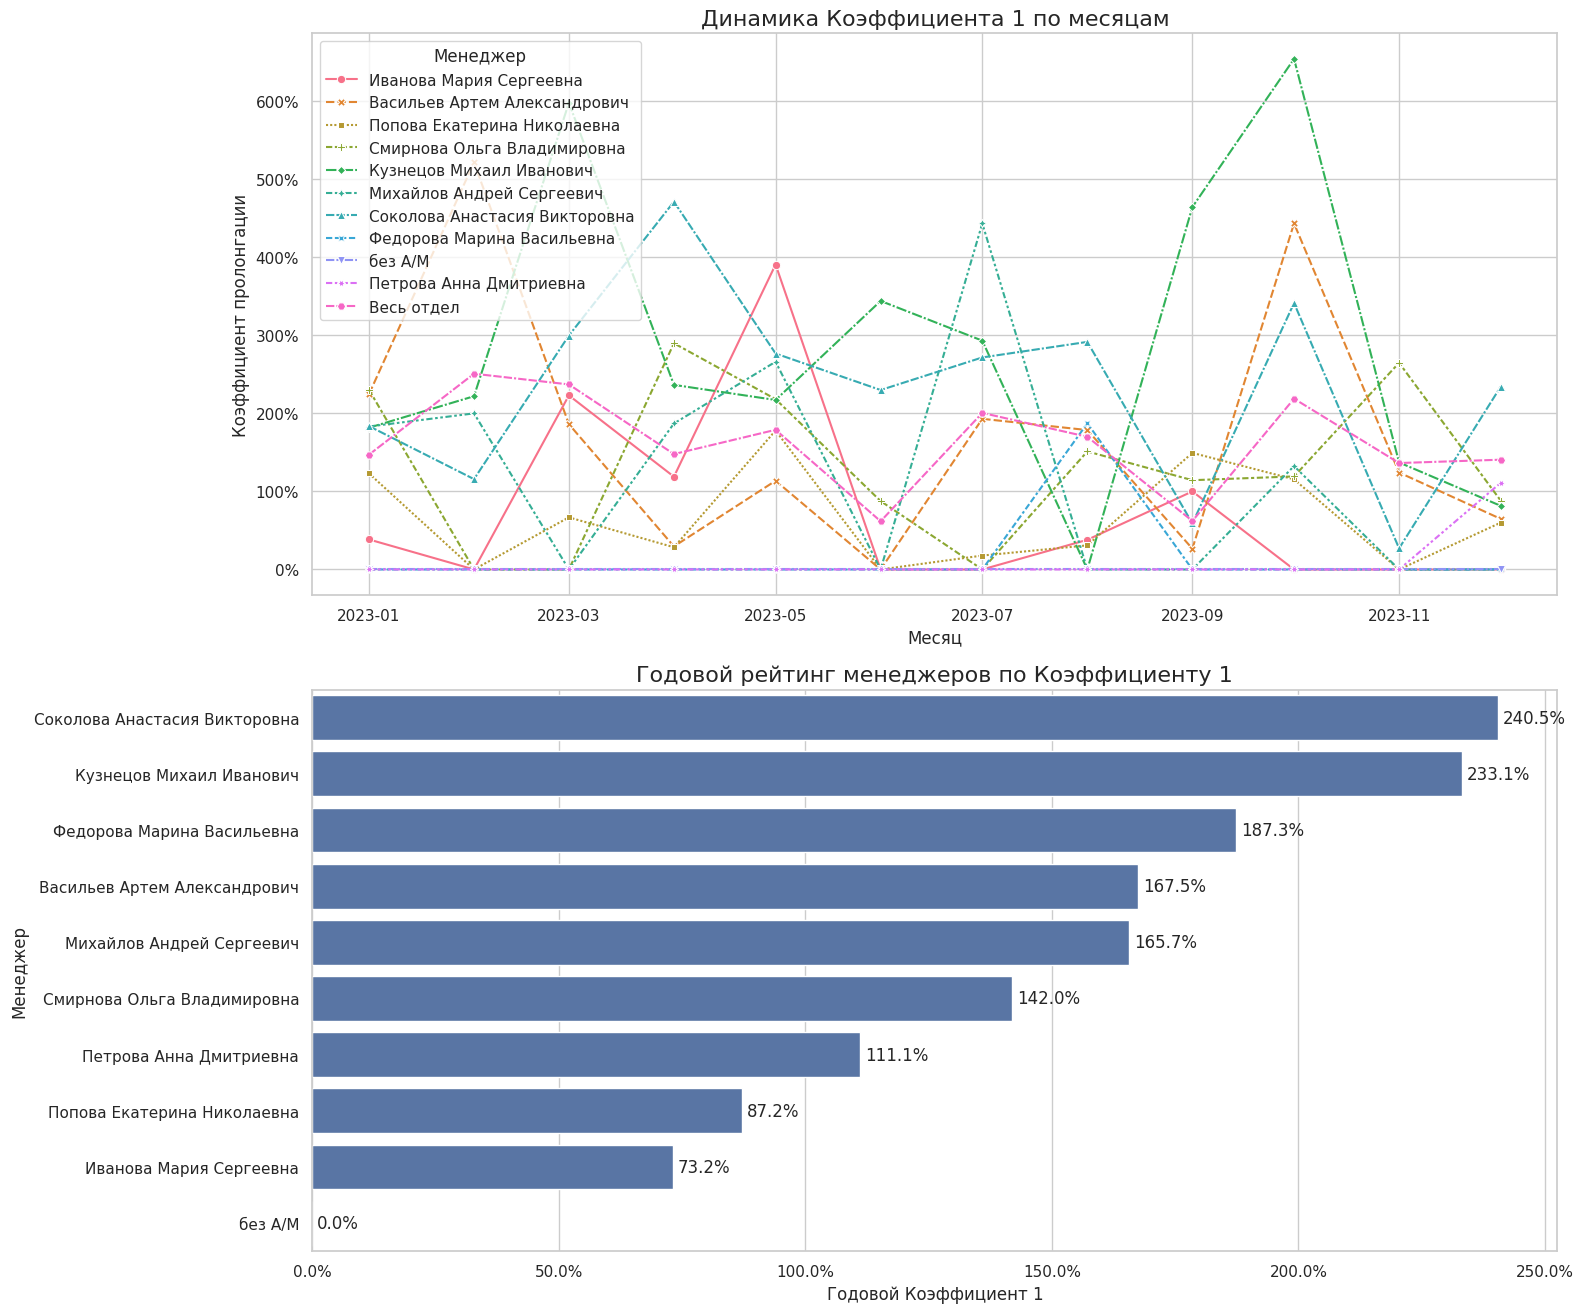

In [1268]:
plotting_graphs(k1_yearly_df, k1_monthly_df, '1')

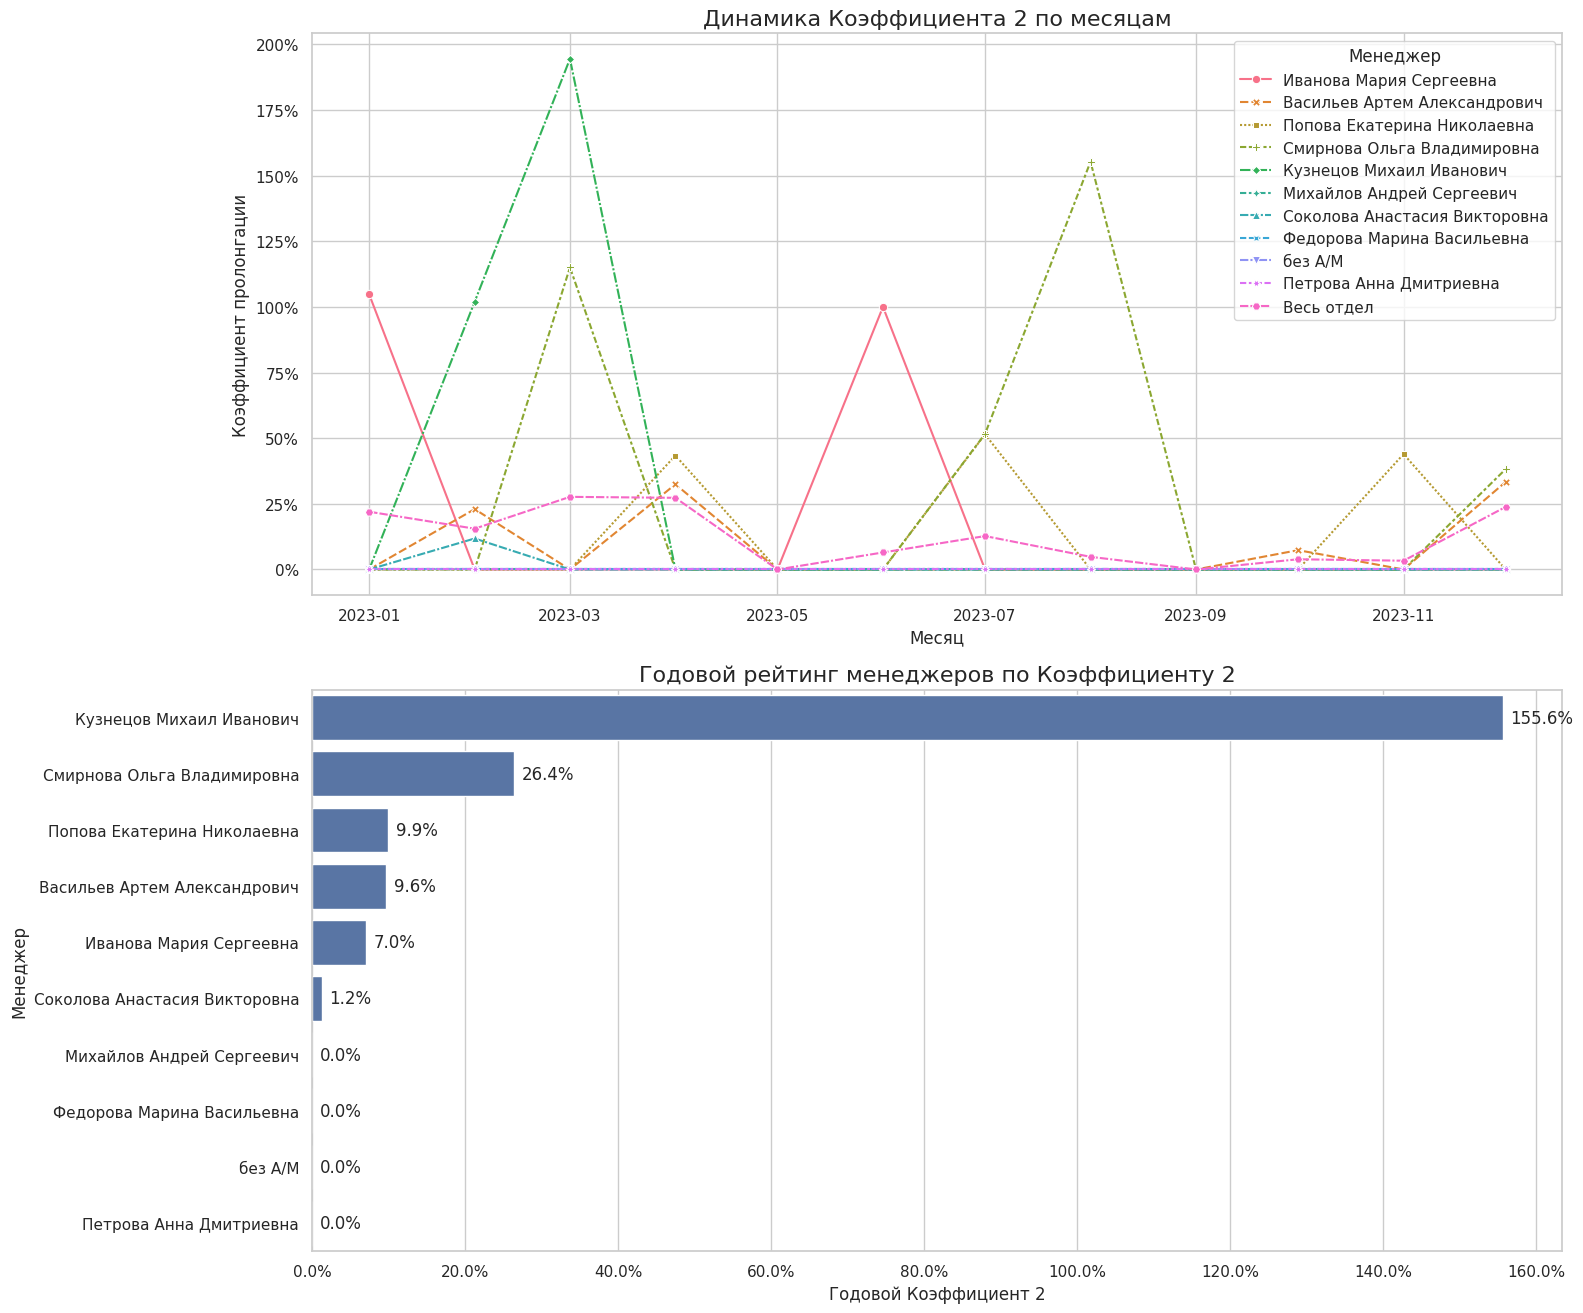

In [1269]:
plotting_graphs(k2_yearly_df, k2_monthly_df, '2')